<a href="https://colab.research.google.com/github/GOLD3PHOENIXsurili/Cognizance_2nd_Year_PT/blob/main/Used_cars_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Don't Get Kicked

![](https://i.imgur.com/Y0X8dsA.jpg)

### Prdicting whether the purchase in the auction is a good or bad buy.

## Introduction

One of the biggest challenges of an auto dealership purchasing a used car at an auto auction is the risk of that the vehicle might have serious issues that prevent it from being sold to customers. The auto community calls these unfortunate purchases "kicks".

Kicked cars often result when there are tampered odometers, mechanical issues the dealer is not able to address, issues with getting the vehicle title from the seller, or some other unforeseen problem. Kick cars can be very costly to dealers after transportation cost, throw-away repair work, and market losses in reselling the vehicle.

In this project we will see the cars which has higher risk of being kick, which can help real value for dealership and provide best selection for the customers,

We will take a look at real world data for 150,000 customers and use machine learning techniques to build the models.

# Data Description

**All the features in the data set are defined as follows:**

- `RefID`: Unique (sequential) number assigned to vehicles
- `IsBadBuy`: Identifies if the kicked vehicle was an avoidable purchase
- `PurchDate`: The Date the vehicle was Purchased at Auction
- `Auction`: Auction provider at which the vehicle was purchased
- `VehYear`: The manufacturer's year of the vehicle
- `VehicleAge`: The Years elapsed since the manufacturer's year
- `Make`: Vehicle Manufacturer
- `Model`: Vehicle Model
- `Trim`: Vehicle Trim Level
- `SubModel`: Vehicle Submodel
- `Color`: Vehicle Color
- `Transmission`: Vehicles transmission type (Automatic, Manual)
- `WheelTypeID`: The type id of the vehicle wheel
- `WheelType`: The vehicle wheel type description (Alloy, Covers)
- `VehOdo`: The vehicles odometer reading
- `Nationality`: The Manufacturer's country
- `Size`: The size category of the vehicle (Compact, SUV, etc.)
- `TopThreeAmericanName`: Identifies if the manufacturer is one of the top three - American manufacturers
- `MMRAcquisitionAuctionAveragePrice`: Acquisition price for this vehicle in - average condition at time of purchase
- `MMRAcquisitionAuctionCleanPrice`: Acquisition price for this vehicle in the above Average condition at time of purchase
- `MMRAcquisitionRetailAveragePrice`: Acquisition price for this vehicle in the retail market in average condition at time of purchase
- `MMRAcquisitonRetailCleanPrice`: Acquisition price for this vehicle in the retail market in above average condition at time of purchase
- `MMRCurrentAuctionAveragePrice`: Acquisition price for this vehicle in average condition as of current day
- `MMRCurrentAuctionCleanPrice`: Acquisition price for this vehicle in the above condition as of current day
- `MMRCurrentRetailAveragePrice`: Acquisition price for this vehicle in the retail market in average condition as of current day
- `MMRCurrentRetailCleanPrice`: Acquisition price for this vehicle in the retail market in above average condition as of current day
- `PRIMEUNIT`: Identifies if the vehicle would have a higher demand than a standard purchase
- `AcquisitionType`: Identifies how the vehicle was aquired (Auction buy, trade in, etc)
- `AUCGUART`: The level guarantee provided by auction for the vehicle (Green light - Guaranteed/arbitratable, Yellow Light - caution/issue, red light - sold as is)
- `KickDate`: Date the vehicle was kicked back to the auction
- `BYRNO`: Unique number assigned to the buyer that purchased the vehicle
- `VNZIP`: Zipcode where the car was purchased
- `VNST`: State where the the car was purchased
- `VehBCost`: Acquisition cost paid for the vehicle at time of purchase
- `IsOnlineSale`: Identifies if the vehicle was originally purchased online
- `WarrantyCost`: Warranty price (term=36month and millage=36K)

In this data we have 32 independent variables and we have the target variable which we have to predict is `IsBadBuy`.



# Project Outline

**Steps that we follow:**

-  Installing and importing all the required libraries.
-  Downloading the data set from Kaggle.
-  Exploratory Data Analysis.
- Feature Engineering.
- Prepare the Dataset for ML Training.
- Train Hardcoded & Baseline Model.
- Train & Evaluate different Models.
- Hyperparameter Tuning.
- Final Model.
- Summary
- Future Work ideas

## Installing and immporting all the libraries

In [2]:
!pip install opendatasets


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import opendatasets as od
import os
import plotly.express as px

## Downloading the Data

We'll use the `opendatasets` library to download the data from Kagggle directly with Jupyter or Colab.The dataset can be downloaded using `od.download`.

In [4]:
url = 'https://www.kaggle.com/competitions/DontGetKicked/data'

In [6]:
od.download(url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: binaykushwaha
Your Kaggle Key: ··········
Extracting archive ./DontGetKicked/DontGetKicked.zip to ./DontGetKicked


In [7]:
os.listdir('./DontGetKicked')

['test.csv',
 'example_entry.csv',
 'test.zip',
 'training.zip',
 'Carvana_Data_Dictionary.txt',
 'training.csv']

In [8]:
train_df = pd.read_csv('DontGetKicked/training.csv')
test_df = pd.read_csv('DontGetKicked/test.csv')

# Exploratory Data Analysis

We have the dataset downloaded and loaded in the dataframe. Let's check the data we have. We have train.csv which contains the training data and test.csv for testing the data.

In [9]:
train_df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72978,73010,1,12/2/2009,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,4836.0,5937.0,NaN,NaN,18111,30212,GA,4200.0,0,993
72979,73011,0,12/2/2009,ADESA,2007,2,CHEVROLET,MALIBU 4C,LS,4D SEDAN LS,...,10151.0,11652.0,NaN,NaN,18881,30212,GA,6200.0,0,1038
72980,73012,0,12/2/2009,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,11831.0,14402.0,NaN,NaN,18111,30212,GA,8200.0,0,1893
72981,73013,0,12/2/2009,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,10099.0,11228.0,NaN,NaN,18881,30212,GA,7000.0,0,1974


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  object 
 3   Auction                            72983 non-null  object 
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  object 
 7   Model                              72983 non-null  object 
 8   Trim                               70623 non-null  object 
 9   SubModel                           72975 non-null  object 
 10  Color                              72975 non-null  object 
 11  Transmission                       72974 non-null  obj

In [11]:
test_df

,RefId,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,Color,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,73015,12/2/2009,ADESA,2005,4,PONTIAC,GRAND PRIX,Bas,4D SEDAN,SILVER,...,8557.0,9752.0,NaN,NaN,18881,30212,GA,6500.0,0,2152
1,73016,12/2/2009,ADESA,2005,4,CHEVROLET,MALIBU V6,LS,4D SEDAN LS,SILVER,...,7562.0,9296.0,NaN,NaN,18111,30212,GA,6300.0,0,1118
2,73017,12/2/2009,ADESA,2006,3,DODGE,DURANGO 2WD V8,Adv,4D SUV 4.7L ADVENTURER,SILVER,...,15340.0,16512.0,NaN,NaN,18111,30212,GA,9700.0,0,1215
3,73018,12/2/2009,ADESA,2002,7,SATURN,L SERIES,L20,4D SEDAN L200,GOLD,...,5725.0,6398.0,NaN,NaN,18881,30212,GA,4150.0,0,1933
4,73019,12/2/2009,ADESA,2007,2,HYUNDAI,ACCENT,GS,2D COUPE GS,BLUE,...,5914.0,7350.0,NaN,NaN,18111,30212,GA,4100.0,0,920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48702,121742,11/17/2010,MANHEIM,2005,5,FORD,FIVE HUNDRED,SEL,4D SEDAN SEL,BLACK,...,9764.0,11395.0,NaN,NaN,20928,33411,FL,7955.0,0,1633
48703,121743,11/17/2010,MANHEIM,2007,3,TOYOTA,COROLLA,CE,4D SEDAN CE,GREEN,...,10283.0,11565.0,NaN,NaN,20928,33411,FL,7035.0,0,594
48704,121744,11/17/2010,MANHEIM,2006,4,KIA,SPECTRA,EX,4D SEDAN EX,BLACK,...,7871.0,9490.0,NO,GREEN,20928,33411,FL,6335.0,0,594
48705,121745,11/17/2010,MANHEIM,2005,5,MAZDA,MAZDA3,s,4D SEDAN GT,SILVER,...,8576.0,9937.0,NO,GREEN,20928,33411,FL,8055.0,0,1038


We can see that training set has 34 columns and test set has 33 columns.

Text(0.5, 1.0, 'Is a Bad Buy')

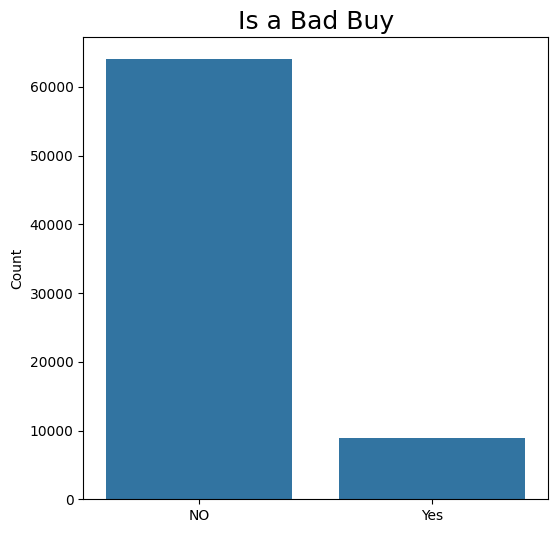

In [12]:
a = train_df.IsBadBuy.value_counts()
plt.figure(figsize=(6,6))
sns.barplot(x=['NO','Yes'],y=a)
plt.ylabel('Count')
plt.title("Is a Bad Buy", fontsize = 18)

**Insights**: In this dataset our target variable is `IsBadBuy`, by analysing the target variable we can see that there are 64K values stating its a good buy and 9K stating its a Bad buy.Hence our data is Imbalanced.

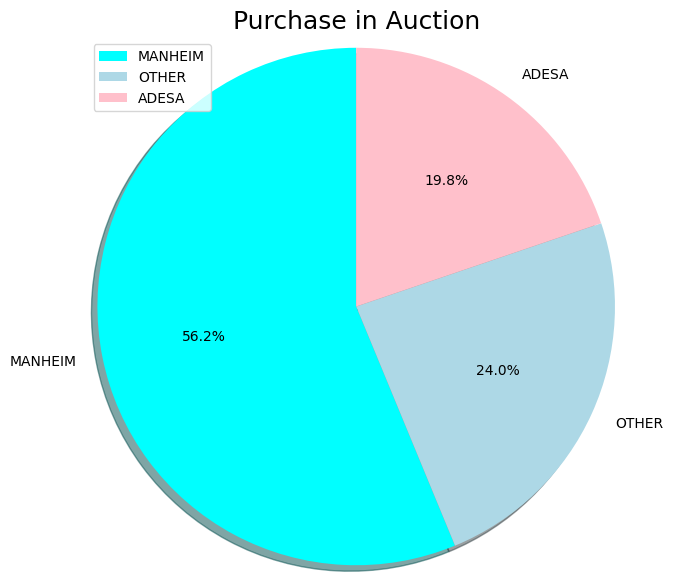

In [13]:
b = train_df.Auction.value_counts()
colors = ['cyan', 'lightblue','pink']
plt.figure(figsize=(7,7))
plt.title('Purchase in Auction',fontsize=18)
plt.pie(b,colors=colors,
        labels =['MANHEIM','OTHER','ADESA'],
        autopct = '%1.1f%%',startangle=90,shadow=True,
       radius = 1.2,explode = (0, 0.0005,0))
plt.legend();

By seeing this chart we can tell that `Manheim` is the Auction place where maximum number of vehicles purchased in the auction.

Text(0.5, 1.0, 'Vehicle Age')

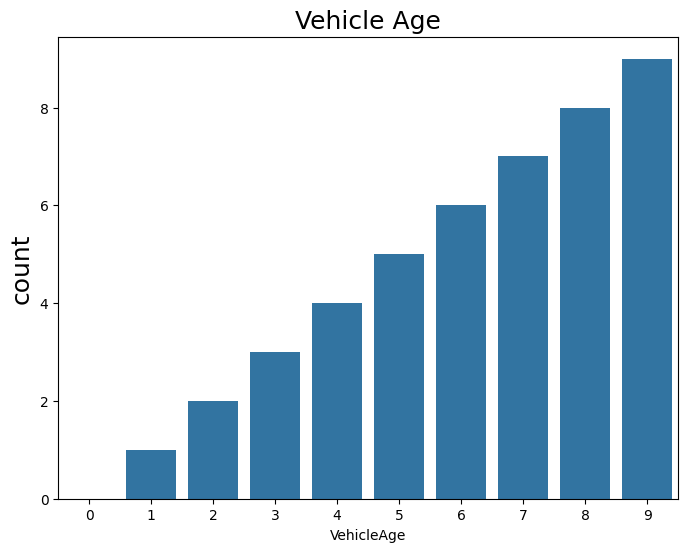

In [14]:
age = pd.DataFrame(train_df.VehicleAge.value_counts())
plt.figure(figsize=(8,6))
sns.barplot(x=age.index,y='VehicleAge',data=age)
plt.ylabel('count',fontsize=18)
plt.title('Vehicle Age',fontsize=18)

Insights: We can see that people prefer to buy the vehicle age of 3 & 4 regarding the counts

Text(0.5, 1.0, 'Make')

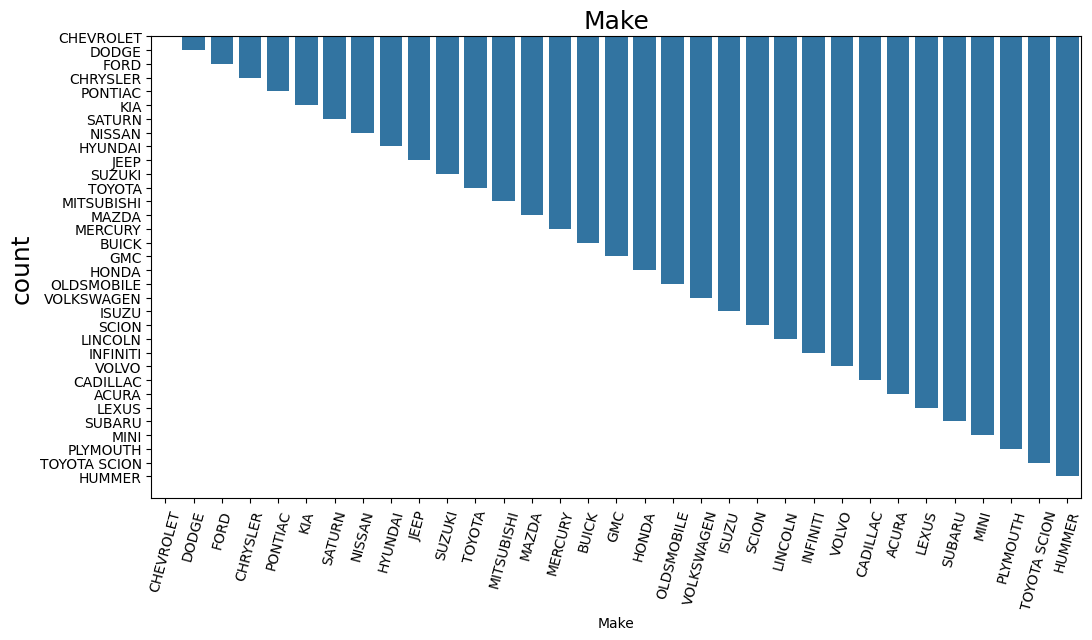

In [15]:
make = pd.DataFrame(train_df.Make.value_counts())
plt.figure(figsize=(12,6))
sns.barplot(x=make.index,y='Make',data=make)
plt.ylabel('count',fontsize=18)
plt.xticks(rotation=75)
plt.title('Make',fontsize=18)

Insights: Chevrolet is the company which people have purchased the vehicle a lot.

In [16]:
px.histogram(train_df, x="VehicleAge", color='IsBadBuy')

Insights: Distibutions of vehicle age with the purchase was a good or bad.

In [17]:
px.histogram(train_df, x= "Make", color='IsBadBuy',width=1000)

Insights: Chevrolet and Dodge are the companies which are in high demand of the market.

In [18]:
px.histogram(train_df, x= "Nationality", color='IsBadBuy')

Insights: Seems like vehicle of America has been purchased a lot and it has the higher demand.

In [19]:
px.histogram(train_df, x= "Size", color='IsBadBuy')

Insights: Majority of the People prefer to purchase the Medium size vehicle.

In [20]:
px.histogram(train_df,x='VNST',width=1000)

Insights: Texas is the state from where the vehicle purchase is more

In [21]:
px.histogram(train_df,x='WheelType',y='IsBadBuy')

Insights: Majority of the vehicle purchased Wheel Type as Alloy , this might be because the Wheel type Special costs more price.

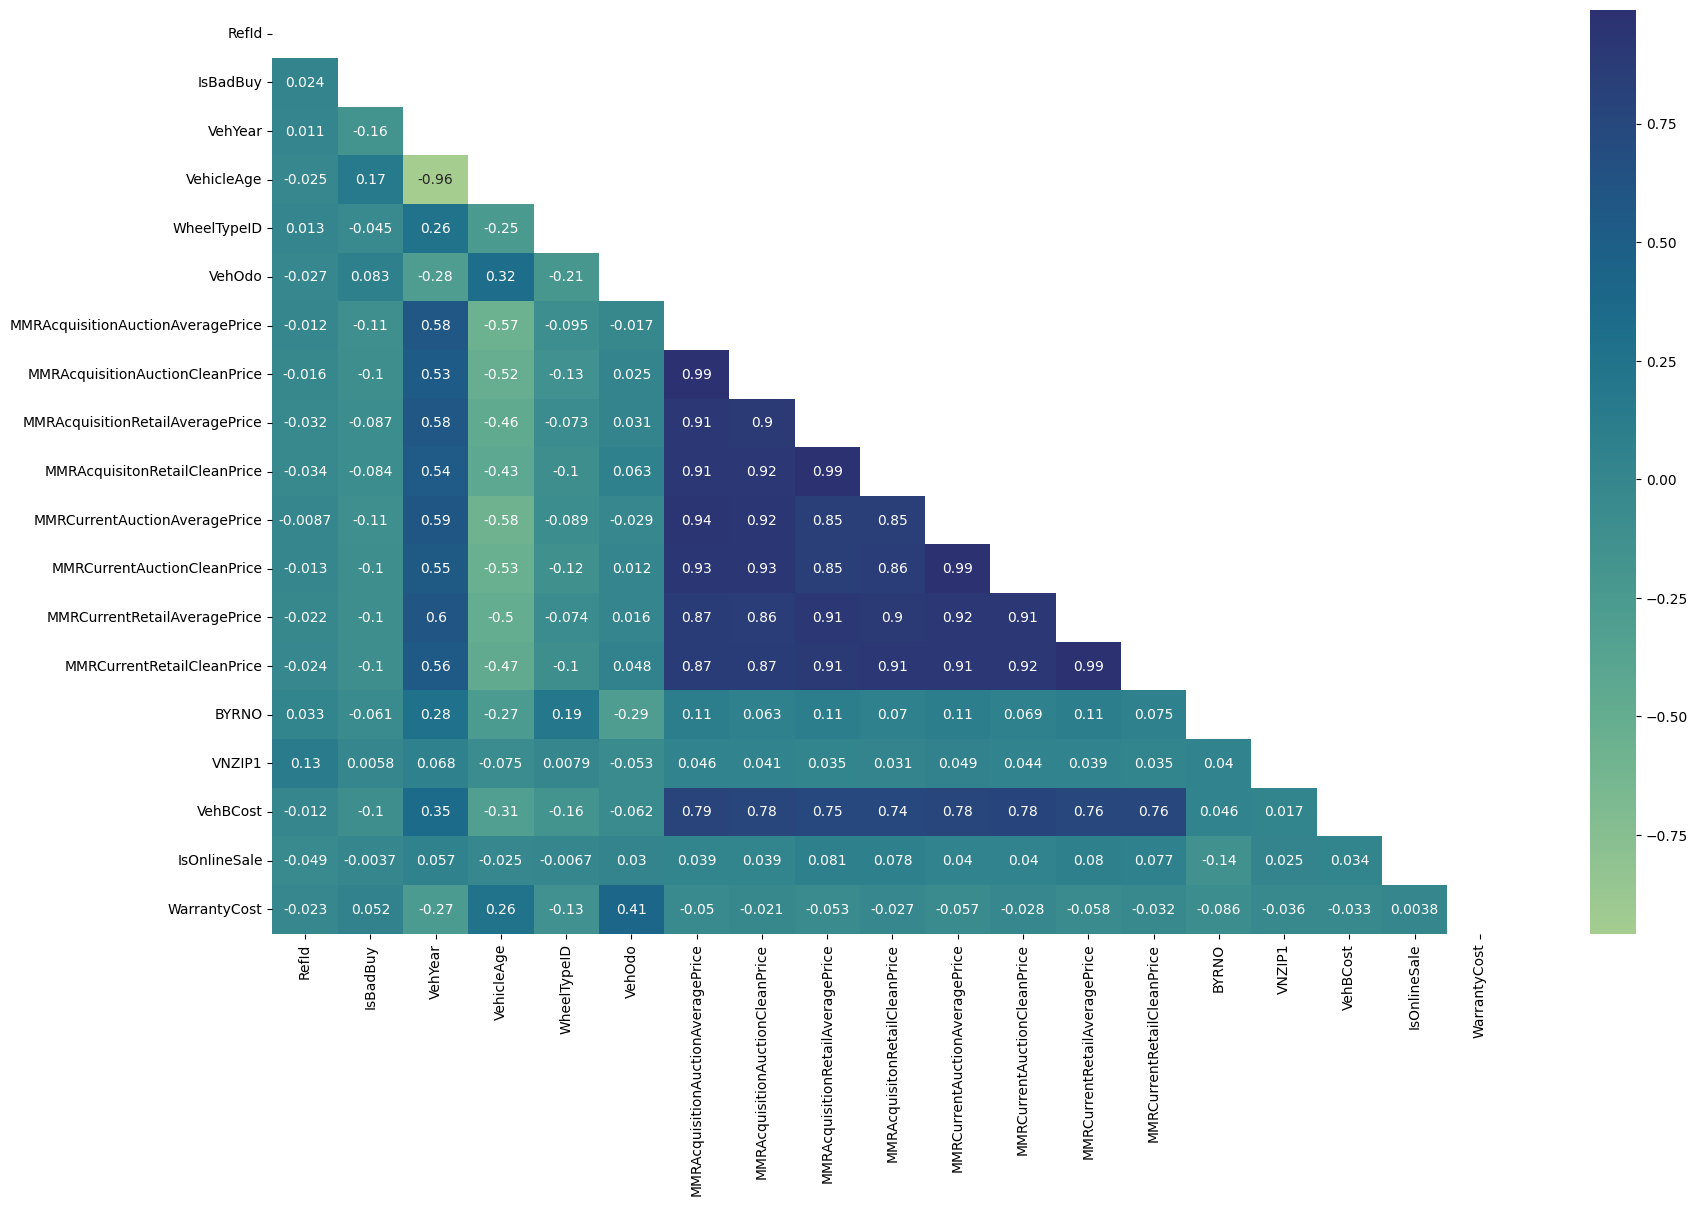

In [24]:
# plt.figure(figsize=(20,12))
# mask_matrix = np.triu(train_df.corr())
# sns.heatmap(train_df.corr(), cmap='crest', annot=True,mask=mask_matrix);


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numeric_df = train_df.select_dtypes(include=[np.number])  # Only keep numeric columns

plt.figure(figsize=(20, 12))
mask_matrix = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), cmap='crest', annot=True, mask=mask_matrix)
plt.show()



Insights: Here we can clearly see that the MMRA price columns are very strongly correlated with each other which might affect the accuracy of what we are trying to achieve.

In [25]:
px.scatter(train_df, x="MMRAcquisitionAuctionAveragePrice", y="MMRAcquisitionRetailAveragePrice",color="IsBadBuy")

Insights : It is clearly obvious that there is a strong positive correlation.

In [26]:
px.scatter(train_df, x = "MMRCurrentAuctionAveragePrice",y = "MMRCurrentAuctionCleanPrice", color='IsBadBuy')

Insights: The above graph is evident there is a positive correlation here and after 20K mark the vehicle seems to fall in Bad Buy.

In [27]:
px.scatter(train_df, x='MMRCurrentRetailAveragePrice', y='MMRCurrentRetailCleanPrice', color='IsBadBuy')

Insights: The above graph is evident there is a positive correlation here and after 20K mark the vehicle seems to fall in Bad Buy.

In [28]:
text_file = open('/content/DontGetKicked/Carvana_Data_Dictionary.txt')
content = text_file.read()
print(content)
text_file.close()

Field Name				Definition
RefID				        Unique (sequential) number assigned to vehicles
IsBadBuy				Identifies if the kicked vehicle was an avoidable purchase 
PurchDate				The Date the vehicle was Purchased at Auction
Auction					Auction provider at which the  vehicle was purchased
VehYear					The manufacturer's year of the vehicle
VehicleAge				The Years elapsed since the manufacturer's year
Make					Vehicle Manufacturer 
Model					Vehicle Model
Trim					Vehicle Trim Level
SubModel				Vehicle Submodel
Color					Vehicle Color
Transmission				Vehicles transmission type (Automatic, Manual)
WheelTypeID				The type id of the vehicle wheel
WheelType				The vehicle wheel type description (Alloy, Covers)
VehOdo					The vehicles odometer reading
Nationality				The Manufacturer's country
Size					The size category of the vehicle (Compact, SUV, etc.)
TopThreeAmericanName			Identifies if the manufacturer is one of the top three American manufacturers
MMRAcquisitionAuctionAveragePrice	Acquisiti

Let's check the null values in the dataset

In [29]:
train_df.isna().sum()*100/len(train_df)

,0
RefId,0.000000
IsBadBuy,0.000000
PurchDate,0.000000
Auction,0.000000
VehYear,0.000000
VehicleAge,0.000000
Make,0.000000
Model,0.000000
Trim,3.233630
SubModel,0.010961


We can see that there are lot of NaN values present in the dataset

In [30]:
train_df.IsOnlineSale.value_counts()

,count
IsOnlineSale,
0,71138
1,1845


# Data Preprocessing

In [31]:
train_df['Transmission'] = train_df['Transmission'].replace({'manual':'MANUAL'})

In [32]:
train_df.isna().sum()

,0
RefId,0
IsBadBuy,0
PurchDate,0
Auction,0
VehYear,0
VehicleAge,0
Make,0
Model,0
Trim,2360
SubModel,8


Inshights: We have approx 90% of nun values in `PrimeUnit` & `Aucguart` so its better to drop them

In [33]:
train_df.drop(['Trim','Model','RefId','VehYear','WheelTypeID','VNZIP1','PRIMEUNIT','AUCGUART','PurchDate'], axis=1, inplace=True)
test_df.drop(['Trim','Model','RefId','VehYear','WheelTypeID','VNZIP1','PRIMEUNIT','AUCGUART','PurchDate'], axis=1, inplace=True)

Removing Unecessary columns which may not impact our model and our model can learn better without this columns

In [34]:
train_df.describe()

,IsBadBuy,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VehBCost,IsOnlineSale,WarrantyCost
count,72983.000000,72983.000000,72983.000000,72965.000000,72965.000000,72965.000000,72965.000000,72668.000000,72668.000000,72668.000000,72668.000000,72983.000000,72983.000000,72983.000000,72983.000000
mean,0.122988,4.176644,71499.995917,6128.909217,7373.636031,8497.034332,9850.928240,6132.081287,7390.681827,8775.723331,10145.385314,26345.842155,6730.934326,0.025280,1276.580985
std,0.328425,1.712210,14578.913128,2461.992768,2722.491986,3156.285284,3385.789541,2434.567723,2686.248852,3090.702941,3310.254351,25717.351219,1767.846435,0.156975,598.846788
min,0.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,1.000000,0.000000,462.000000
25%,0.000000,3.000000,61837.000000,4273.000000,5406.000000,6280.000000,7493.000000,4275.000000,5414.000000,6536.000000,7784.000000,17212.000000,5435.000000,0.000000,837.000000
50%,0.000000,4.000000,73361.000000,6097.000000,7303.000000,8444.000000,9789.000000,6062.000000,7313.000000,8729.000000,10103.000000,19662.000000,6700.000000,0.000000,1155.000000
75%,0.000000,5.000000,82436.000000,7765.000000,9021.000000,10651.000000,12088.000000,7736.000000,9013.000000,10911.000000,12309.000000,22808.000000,7900.000000,0.000000,1623.000000
max,1.000000,9.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,45469.000000,1.000000,7498.000000


In [35]:
train_targets = train_df['IsBadBuy']
train_df.drop('IsBadBuy',axis=1, inplace= True)

Splitting the Dependent variable and independent variables

In [36]:
train_df.head()

,Auction,VehicleAge,Make,SubModel,Color,Transmission,WheelType,VehOdo,Nationality,Size,...,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,ADESA,3,MAZDA,4D SEDAN I,RED,AUTO,Alloy,89046,OTHER ASIAN,MEDIUM,...,13600.0,7451.0,8552.0,11597.0,12409.0,21973,FL,7100.0,0,1113
1,ADESA,5,DODGE,QUAD CAB 4.7L SLT,WHITE,AUTO,Alloy,93593,AMERICAN,LARGE TRUCK,...,12572.0,7456.0,9222.0,11374.0,12791.0,19638,FL,7600.0,0,1053
2,ADESA,4,DODGE,4D SEDAN SXT FFV,MAROON,AUTO,Covers,73807,AMERICAN,MEDIUM,...,8457.0,4035.0,5557.0,7146.0,8702.0,19638,FL,4900.0,0,1389
3,ADESA,5,DODGE,4D SEDAN,SILVER,AUTO,Alloy,65617,AMERICAN,COMPACT,...,5690.0,1844.0,2646.0,4375.0,5518.0,19638,FL,4100.0,0,630
4,ADESA,4,FORD,2D COUPE ZX3,SILVER,MANUAL,Covers,69367,AMERICAN,COMPACT,...,8707.0,3247.0,4384.0,6739.0,7911.0,19638,FL,4000.0,0,1020


### Conclusions


1. We can drop **`Model`** & **`Trim`** as they have alot of categories and model wont be able to learn all of them.


2. Note: **`WheelType`** and **`WheelTypeID`** are one and the same. One of them is containing numeric categories and other as string. Its better we drop **`WheelTypeID`** as the other column has type of metal used for making the wheel which might help us understand the importance of a particular metal used in making the wheel

3.  **`VehYear`** might not play a crucial role as we have  **`VehicleAge`** as a column. The  **`PurchDate`** varies and similarly  **`VehYear`** varies.The only thing that matters is how much old the vehicle is at the time of resale. Thus `drop` **`VehYear`**


# Encoding & Imputing Technique

It is always a good practice to indentify the numerical and catagorical columns so that it becomes easier to work on them.



In [37]:
num_cols = train_df.select_dtypes(exclude='object').columns.tolist()

We all know that machine learning models cannot work with missing data therefore we will need to fill these missing values and this process is called imputation.

In [38]:
from sklearn.impute import SimpleImputer

In [39]:
imputer = SimpleImputer(strategy='mean')

Implementing simple imputer so that missing values can be filled with mean

In [41]:
# train_df[num_cols] = imputer.transform(train_df[num_cols])


from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # or 'median', 'most_frequent', etc.

# Fit the imputer on the numeric columns
imputer.fit(train_df[num_cols])

# Now transform
train_df[num_cols] = imputer.transform(train_df[num_cols])


In [42]:
imputer.fit(test_df[num_cols])
test_df[num_cols] = imputer.transform(test_df[num_cols])

In [43]:
train_df.isna().sum()

,0
Auction,0
VehicleAge,0
Make,0
SubModel,8
Color,8
Transmission,9
WheelType,3174
VehOdo,0
Nationality,5
Size,5


Simple Imputer doesnot work for the categorical values or objects so that we are applying different stratergy for filling missing values

In [44]:
train_df = train_df.apply(lambda x: x.fillna(x.value_counts().index[0]))

In [45]:
test_df = test_df.apply(lambda x: x.fillna(x.value_counts().index[0]))

In [46]:
test_df.isnull().sum()

,0
Auction,0
VehicleAge,0
Make,0
SubModel,0
Color,0
Transmission,0
WheelType,0
VehOdo,0
Nationality,0
Size,0


In [47]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

Selecting some specific columns so that label encoding can be applied because label encoding takes the labels as `rank`.

In [48]:
train_df['Auction']= label_encoder.fit_transform(train_df["Auction"])
train_df['Transmission']= label_encoder.fit_transform(train_df['Transmission'])
train_df['WheelType']= label_encoder.fit_transform(train_df['WheelType'])
train_df['Nationality']= label_encoder.fit_transform(train_df['Nationality'])
train_df['TopThreeAmericanName']= label_encoder.fit_transform(train_df['TopThreeAmericanName'])

test_df['Auction']= label_encoder.fit_transform(test_df["Auction"])
test_df['Transmission']= label_encoder.fit_transform(test_df['Transmission'])
test_df['WheelType']= label_encoder.fit_transform(test_df['WheelType'])
test_df['Nationality']= label_encoder.fit_transform(test_df['Nationality'])
test_df['TopThreeAmericanName']= label_encoder.fit_transform(test_df['TopThreeAmericanName'])

In [49]:
train_df.head()

,Auction,VehicleAge,Make,SubModel,Color,Transmission,WheelType,VehOdo,Nationality,Size,...,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,0,3.0,MAZDA,4D SEDAN I,RED,0,0,89046.0,2,MEDIUM,...,13600.0,7451.0,8552.0,11597.0,12409.0,21973.0,FL,7100.0,0.0,1113.0
1,0,5.0,DODGE,QUAD CAB 4.7L SLT,WHITE,0,0,93593.0,0,LARGE TRUCK,...,12572.0,7456.0,9222.0,11374.0,12791.0,19638.0,FL,7600.0,0.0,1053.0
2,0,4.0,DODGE,4D SEDAN SXT FFV,MAROON,0,1,73807.0,0,MEDIUM,...,8457.0,4035.0,5557.0,7146.0,8702.0,19638.0,FL,4900.0,0.0,1389.0
3,0,5.0,DODGE,4D SEDAN,SILVER,0,0,65617.0,0,COMPACT,...,5690.0,1844.0,2646.0,4375.0,5518.0,19638.0,FL,4100.0,0.0,630.0
4,0,4.0,FORD,2D COUPE ZX3,SILVER,1,1,69367.0,0,COMPACT,...,8707.0,3247.0,4384.0,6739.0,7911.0,19638.0,FL,4000.0,0.0,1020.0


In [50]:
category_col = train_df.select_dtypes(include = 'object').columns.tolist()

**Encoding Categorical Data:**

Since machine learning models can only be trained with numeric data, we need to convert categorical data to numbers. A very common technique is to use one-hot encoding for categorical columns.

<img src="https://i.imgur.com/n8GuiOO.png" width="640">

One hot encoding involves adding a new binary (0/1) column for each unique category of a categorical column.


We will use `OneHotEncoder` from `sklearn.preprocessing` to achive this goal.

In [51]:
from sklearn.preprocessing import OneHotEncoder

In [55]:
# encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
# encoder.fit(train_df[category_col])
# encoder.fit(test_df[category_col])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit only on training data
encoder.fit(train_df[category_col])

# Transform both
train_encoded = encoder.transform(train_df[category_col])
test_encoded = encoder.transform(test_df[category_col])



In [57]:
# encoded_cols = list(encoder.get_feature_names(category_col))

encoded_cols = list(encoder.get_feature_names_out(category_col))


After fitting the categorical columns to the `OneHotEncoder` object, the encoder creates a list of new columns from all the categories in the columns and we can access them using `get_feature_names_out`.

Now we will use these encoded columns names to transform the columns into encoded columns.

In [59]:
# train_df[encoded_cols] = encoder.transform(train_df[category_col])
# test_df[encoded_cols] = encoder.transform(test_df[category_col])

import pandas as pd

# Transform categorical data
train_encoded = pd.DataFrame(encoder.transform(train_df[category_col]), columns=encoded_cols, index=train_df.index)
test_encoded = pd.DataFrame(encoder.transform(test_df[category_col]), columns=encoded_cols, index=test_df.index)

# Drop the original categorical columns if no longer needed
train_df = train_df.drop(columns=category_col)
test_df = test_df.drop(columns=category_col)

# Concatenate encoded columns
train_df = pd.concat([train_df, train_encoded], axis=1)
test_df = pd.concat([test_df, test_encoded], axis=1)


In [60]:
train_df[encoded_cols]

,Make_ACURA,Make_ACURA,Make_BUICK,Make_BUICK,Make_CADILLAC,Make_CADILLAC,Make_CHEVROLET,Make_CHEVROLET,Make_CHRYSLER,Make_CHRYSLER,...,VNST_TX,VNST_TX,VNST_UT,VNST_UT,VNST_VA,VNST_VA,VNST_WA,VNST_WA,VNST_WV,VNST_WV
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72978,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72979,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72980,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
72981,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Scaling Down the Data

In [61]:
train_df.columns.tolist()

['Auction',
 'VehicleAge',
 'Transmission',
 'WheelType',
 'VehOdo',
 'Nationality',
 'TopThreeAmericanName',
 'MMRAcquisitionAuctionAveragePrice',
 'MMRAcquisitionAuctionCleanPrice',
 'MMRAcquisitionRetailAveragePrice',
 'MMRAcquisitonRetailCleanPrice',
 'MMRCurrentAuctionAveragePrice',
 'MMRCurrentAuctionCleanPrice',
 'MMRCurrentRetailAveragePrice',
 'MMRCurrentRetailCleanPrice',
 'BYRNO',
 'VehBCost',
 'IsOnlineSale',
 'WarrantyCost',
 'Make_ACURA',
 'Make_BUICK',
 'Make_CADILLAC',
 'Make_CHEVROLET',
 'Make_CHRYSLER',
 'Make_DODGE',
 'Make_FORD',
 'Make_GMC',
 'Make_HONDA',
 'Make_HUMMER',
 'Make_HYUNDAI',
 'Make_INFINITI',
 'Make_ISUZU',
 'Make_JEEP',
 'Make_KIA',
 'Make_LEXUS',
 'Make_LINCOLN',
 'Make_MAZDA',
 'Make_MERCURY',
 'Make_MINI',
 'Make_MITSUBISHI',
 'Make_NISSAN',
 'Make_OLDSMOBILE',
 'Make_PLYMOUTH',
 'Make_PONTIAC',
 'Make_SATURN',
 'Make_SCION',
 'Make_SUBARU',
 'Make_SUZUKI',
 'Make_TOYOTA',
 'Make_TOYOTA SCION',
 'Make_VOLKSWAGEN',
 'Make_VOLVO',
 'SubModel_2D CONV

Another good practice is to scale numeric features to a small range of values e.g. (0,1) or (−1,1). Scaling numeric features ensures that no particular feature has a disproportionate impact on the model's loss. Optimization algorithms also work better in practice with smaller numbers.

We will use `MinMaxScaler` from `sklearn.preprocessing` to scale numeric features.

In [62]:
from sklearn.preprocessing import MinMaxScaler

In [66]:
# scaler = MinMaxScaler()
# scaler.fit(train_df[num_cols])

train_df[num_cols] = scaler.transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

In [67]:
train_df[num_cols] = scaler.transform(train_df[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

In [68]:
train_df[num_cols].describe()

,VehicleAge,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VehBCost,IsOnlineSale,WarrantyCost
count,72983.000000,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,7.298300e+04,72983.000000,7.298300e+04
mean,0.000637,-4.351120e-02,3.763918e-15,3.994915e-15,3.642916e-15,3.326890e-15,3.765866e-15,4.004150e-15,3.762398e-15,3.568684e-15,-8.440738e-03,-2.199397e-05,0.025280,-6.567164e-02
std,0.000261,5.674332e-14,1.511785e-15,1.474819e-15,1.353021e-15,1.143320e-15,1.491899e-15,1.452221e-15,1.322208e-15,1.161881e-15,1.294945e-14,4.136387e-16,0.156975,2.446180e-13
min,0.000000,-4.351120e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-8.440738e-03,-2.199397e-05,0.000000,-6.567164e-02
25%,0.000457,-4.351120e-02,2.624157e-15,2.929424e-15,2.692840e-15,2.530900e-15,2.631527e-15,2.939176e-15,2.808168e-15,2.742278e-15,-8.440738e-03,-2.199397e-05,0.000000,-6.567164e-02
50%,0.000610,-4.351120e-02,3.744936e-15,3.957729e-15,3.621036e-15,3.306313e-15,3.731425e-15,3.970190e-15,3.752656e-15,3.557645e-15,-8.440738e-03,-2.199397e-05,0.000000,-6.567164e-02
75%,0.000762,-4.351120e-02,4.768682e-15,4.887429e-15,4.565952e-15,4.082401e-15,4.748416e-15,4.879303e-15,4.671848e-15,4.329394e-15,-8.440738e-03,-2.199397e-05,0.000000,-6.567164e-02
max,0.001372,-4.351120e-02,2.193778e-14,1.996960e-14,1.675469e-14,1.400945e-14,2.193778e-14,1.996960e-14,1.675469e-14,1.444374e-14,-8.440738e-03,-2.199397e-05,1.000000,-6.567164e-02


In [71]:
# train_df.drop(['Make','SubModel','Color','Size','VNST'],axis=1,inplace=True)
# test_df.drop(['Make','SubModel','Color','Size','VNST'],axis=1,inplace=True)

train_df.drop(['Make', 'SubModel', 'Color', 'Size', 'VNST'], axis=1, inplace=True, errors='ignore')
test_df.drop(['Make', 'SubModel', 'Color', 'Size', 'VNST'], axis=1, inplace=True, errors='ignore')


As we applied one hot encoding to the above columns lets drop these columns from the dataset.

# Training , Validation and Test Set

**Training, Validation and Test Sets:**

While building real-world machine learning models, it is quite common to split the dataset into three parts:

1. **Training set** - used to train the model, i.e., compute the loss and adjust the model's weights using an optimization technique.


2. **Validation set** - used to evaluate the model during training, tune model hyperparameters (optimization technique, regularization etc.), and pick the best version of the model. Picking a good validation set is essential for training models that generalize well. [Learn more here.](https://www.fast.ai/2017/11/13/validation-sets/)


3. **Test set** - used to compare different models or approaches and report the model's final accuracy. For many datasets, test sets are provided separately. The test set should reflect the kind of data the model will encounter in the real-world, as closely as feasible.


<img src="https://i.imgur.com/j8eITrK.png" width="480">


As a general rule of thumb you can use around 60% of the data for the training set, 20% for the validation set and 20% for the test set. If a separate test set is already provided, you can use a 75%-25% training-validation split.


When rows in the dataset have no inherent order, it's common practice to pick random subsets of rows for creating test and validation sets. This can be done using the `train_test_split` utility from `scikit-learn`. Learn more about it here: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [72]:
from sklearn.model_selection import train_test_split

In [73]:
inputs, val_inputs, train_targets, val_targets = train_test_split(train_df,train_targets, test_size=0.20, random_state=42)

# Dumb Model

It's always a good idea to build a baseline or a dumb model first before training a machine learning model to actually have the baseline, which we need to perform better from.

In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix

We will use the `accuracy_score` from `sklearn.metrics` library to test the accuracy of models by computing the percentage of matching values between the predictions and actual targets

In [75]:
dum_model_outs = np.zeros(len(inputs))
accuracy_score(dum_model_outs,train_targets)

0.8761860720035625

Our Dum Model saying 'No' has the accuracy of 87%.

# Model 1: Logistic Regression

We wiil make our first model which is going to be `LogisticRegression` model.
We will use `LogisticRegression` from `sklearn.linear_model` to build the model.

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [78]:
lr_model = LogisticRegression(random_state = 42,solver='liblinear',class_weight={0: 1, 1:1.6})
lr_model.fit(inputs, train_targets)

LogisticRegression(class_weight={0: 1, 1: 1.6}, random_state=42,
                   solver='liblinear')

We have made the lr_model object and have fitted the training inputs to the model.
Next we will get the predictions from the model and check the accuracy score.

In [79]:
lr_model.score(inputs, train_targets)

0.8768882951392457

In [80]:
lr_model.score(val_inputs, val_targets)

0.8771665410700829

In [81]:
train_preds = lr_model.predict(inputs)

**Confusion Matrix:**

A Confusion matrix is an N x N matrix used for evaluating the performance of a classification model, where N is the number of target classes. The matrix compares the actual target values with those predicted by the machine learning model. This gives us a holistic view of how well our classification model is performing and what kinds of errors it is making.

For a binary classification problem, we would have a 2 x 2 matrix as shown below with 4 values:

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2020/04/Basic-Confusion-matrix.png)

- The target variable has two values: Positive or Negative
- The columns represent the actual values of the target variable
- The rows represent the predicted values of the target variable


Here TP and TN means that the the predicted value matches the actual value, FN means that model predicted **False** but the actual value was **True** and FP means that the model predicted **True** but the actual value was **False**.

In [82]:
confusion_matrix(train_targets, train_preds, normalize = 'pred')

array([[0.87948147, 0.45474614],
       [0.12051853, 0.54525386]])

In the above matrix we can see that the **TP** and **TN** have a percentage of 88% and 45% repectively.


In [83]:
accuracy = accuracy_score(train_targets, train_preds)
accuracy

0.8768882951392457

In [84]:
val_preds = lr_model.predict(val_inputs)

In [85]:
confusion_matrix(val_targets, val_preds, normalize = 'pred')

array([[0.88203994, 0.68253968],
       [0.11796006, 0.31746032]])

In the above matrix we can see that the **TP** and **TN** have a percentage of 88% and 41% repectively.


In [86]:
preds=lr_model.predict(test_df)

# Model 2: KNN Classifier

We will create KNN classifier model.

We will use `KNeighborsClassifier` from `sklearn.neighbors` to build the model.


In [87]:
from sklearn.neighbors import KNeighborsClassifier
KNN = KNeighborsClassifier(algorithm='auto',leaf_size=30,metric='minkowski',n_neighbors=11,weights='uniform')

In [88]:
KNN.fit(inputs, train_targets)

KNeighborsClassifier(n_neighbors=11)

In [89]:
KNN.score(inputs, train_targets)

0.8772308430103107

In [90]:
KNN.score(val_inputs, val_targets)

0.879084743440433

It seems we are getting the score of 87 in the validation set but `KNeighborsClassifier` takes some time to give the predictions.

In [92]:
# preds=KNN.predict(test_df)
# submission_df['IsBadBuy']=preds

import pandas as pd

submission_df = pd.DataFrame()
submission_df['IsBadBuy'] = preds


# Model 3: Decission Tree Classifier

Next We will create our 'Descision Tree' model.

We will use `DecisionTreeClassifier` from `sklearn.tree` to build the model.

In [96]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(inputs, train_targets)


DecisionTreeClassifier(random_state=42)

In [97]:
model.fit(inputs, train_targets)

DecisionTreeClassifier(random_state=42)

In [98]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [99]:
train_preds = model.predict(inputs)

In [100]:
train_preds

array([0, 0, 0, ..., 0, 0, 0])

In [101]:
pd.value_counts(train_preds)

<ipython-input-101-5a0b2543de7a>:1: FutureWarning:

pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.



,count
0,51204
1,7182


In [102]:
train_probs = model.predict_proba(inputs)
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [103]:
accuracy_score(train_targets, train_preds)

0.9990922481416779

In [104]:
model.score(val_inputs, val_targets)

0.7992738233883675

It seems we are getting the accuracy of 79% in the validation set lets apply some hyperparameter here to increase the accuracy

In [105]:
val_targets.value_counts() / len(val_targets)

,count
IsBadBuy,
0,0.880318
1,0.119682


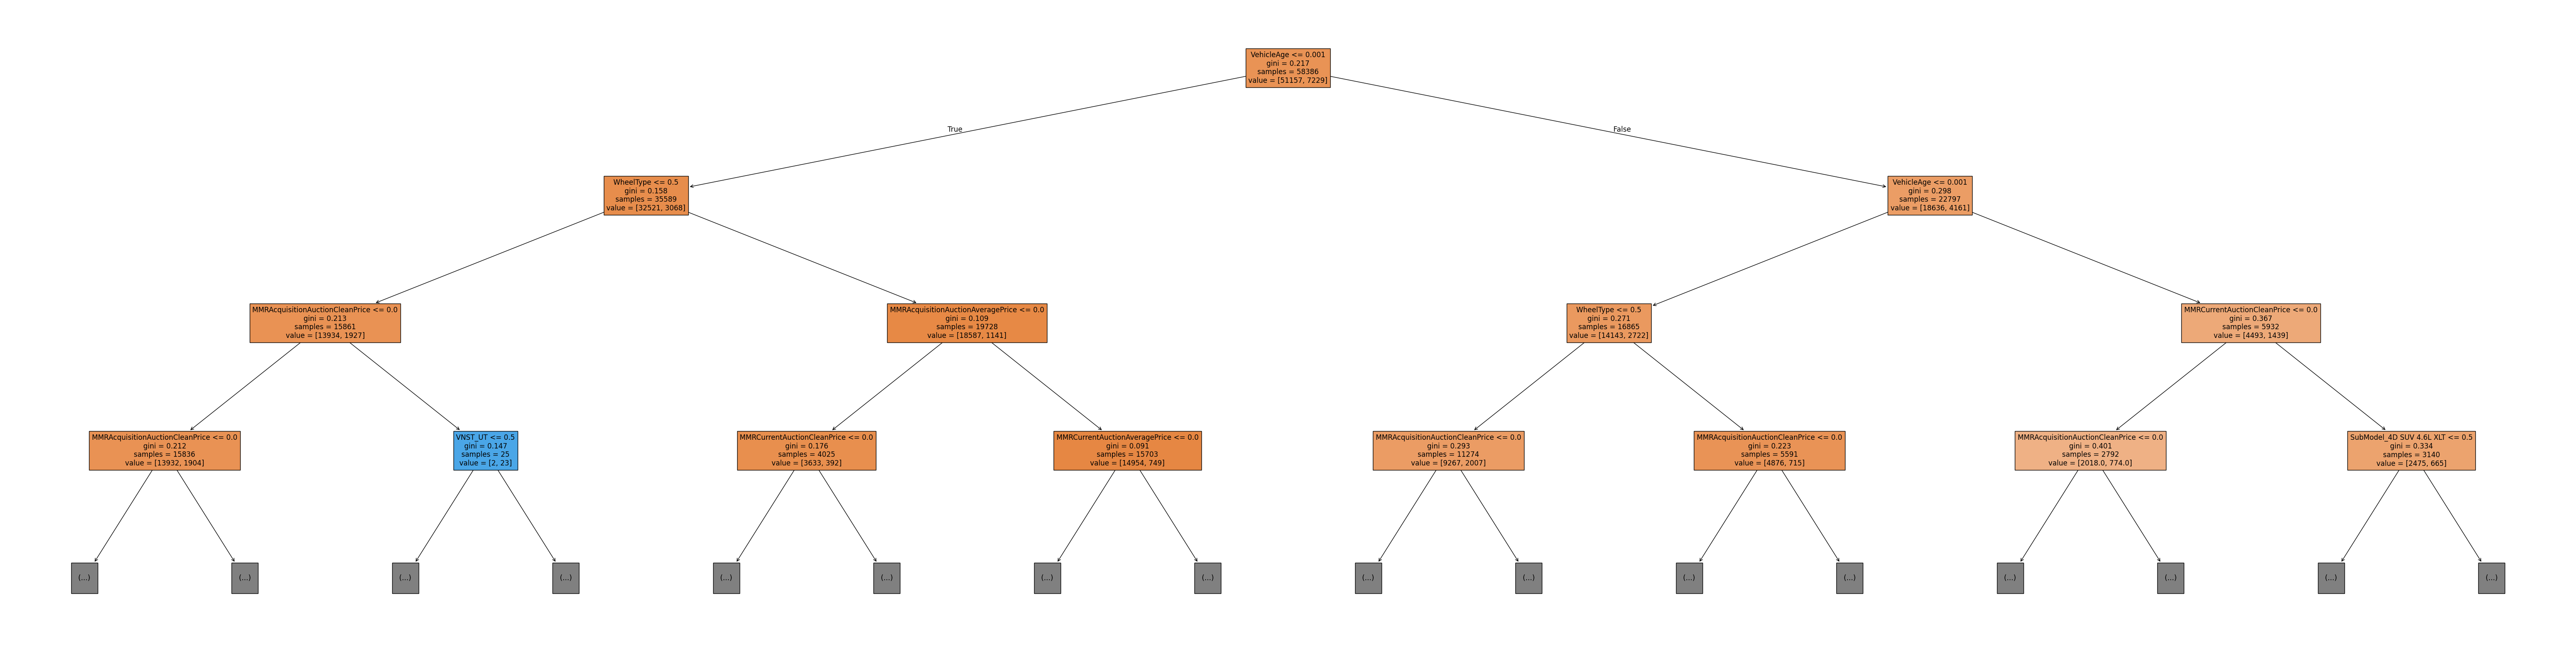

In [106]:
from sklearn.tree import plot_tree, export_text
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=inputs.columns, max_depth=3, filled=True);

In [107]:
model.tree_.max_depth

69

In [108]:
importance_df = pd.DataFrame({
    'feature': inputs.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

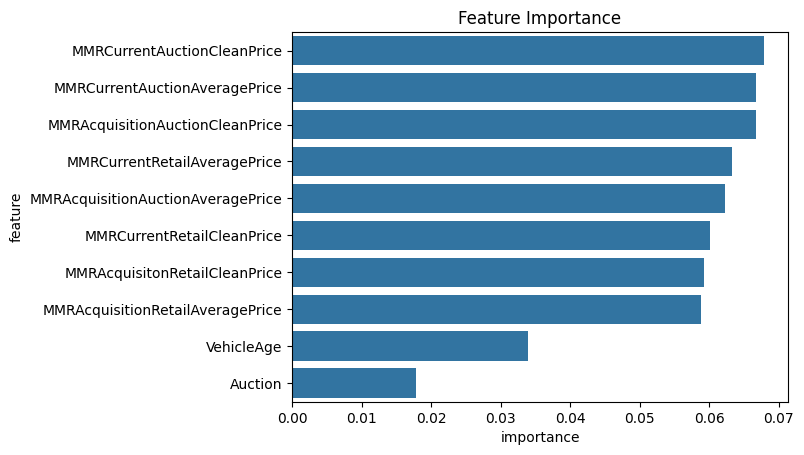

In [109]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

Importance of the feature in the dataset

In [110]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

applying different values of max_depth of the tree to increase the accuracy

In [111]:
model.fit(inputs, train_targets)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [112]:
model.score(inputs, train_targets)

0.8765457472681807

In [113]:
model.score(val_inputs, val_targets)

0.8803863807631706

Now we can see that just by increasing the max depth of the tree we are getting the accuracy of 88% which is far better than 79%

In [114]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(inputs, train_targets)
    train_acc = 1 - model.score(inputs, train_targets)
    val_acc = 1 - model.score(val_inputs, val_targets)
    return {'Max Depth': md, 'Training Error': train_acc, 'Validation Error': val_acc}

In [115]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

In [116]:
errors_df

,Max Depth,Training Error,Validation Error
0,1,0.123814,0.119682
1,2,0.123814,0.119682
2,3,0.123454,0.119614
3,4,0.123437,0.119614
4,5,0.123146,0.119819
5,6,0.122889,0.120025
6,7,0.121964,0.122628
7,8,0.120371,0.122902
8,9,0.118145,0.125916
9,10,0.114582,0.127629


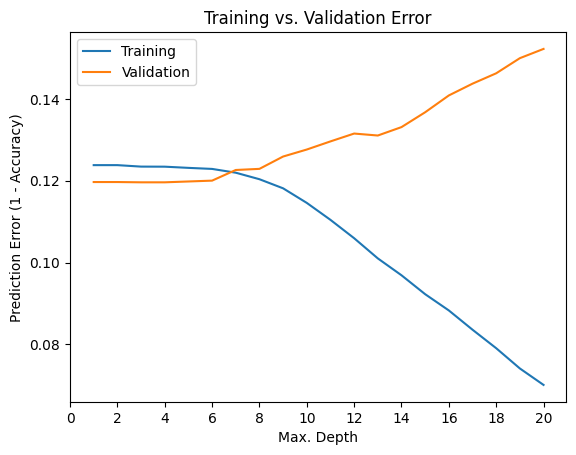

In [117]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

Applying different hyperparameter values to tune the dataset

In [118]:
model = DecisionTreeClassifier(max_depth=4,max_leaf_nodes=50,random_state=42).fit(inputs, train_targets)
model.score(val_inputs, val_targets)

0.8803863807631706

Hence we got the accuracy of 88% in Decission tree model

In [119]:
preds=model.predict(test_df)
submission_df['IsBadBuy']=preds

# Model 4: RandomForest Calssifier

Next we will make our random forest classifier model and we will use `RandomForestClassifier` from `sklearn.ensemble`.

In [120]:
from sklearn.ensemble import RandomForestClassifier

In [121]:
model = RandomForestClassifier(n_jobs=-1, random_state=42)

In [122]:
model.fit(inputs, train_targets)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [123]:
model.score(inputs, train_targets)

0.9990751207481245

In [124]:
model.score(val_inputs, val_targets)

0.8780571350277454

In [125]:
train_probs = model.predict_proba(inputs)
train_probs

array([[0.957     , 0.043     ],
       [0.97      , 0.03      ],
       [0.96333333, 0.03666667],
       ...,
       [1.        , 0.        ],
       [0.96      , 0.04      ],
       [0.99      , 0.01      ]])

In [126]:
preds=model.predict_proba(test_df)
submission_df['IsBadBuy']=preds[:,1]
submission_df.to_csv('rf_Submissions.csv',index=False)

In [127]:
importance_df = pd.DataFrame({
    'feature': inputs.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

<ipython-input-128-e48ad8e44a85>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




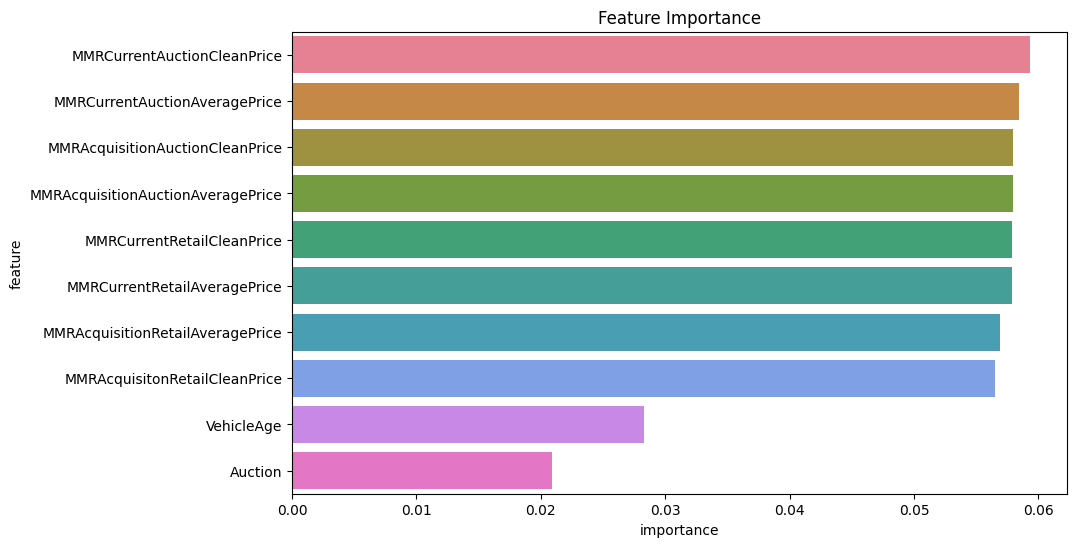

In [128]:
plt.figure(figsize=(10,6))
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10),palette='husl',x='importance', y='feature');
plt.show()

In [129]:
def test_params(**params):
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params).fit(inputs, train_targets)
    return model.score(inputs, train_targets), model.score(val_inputs, val_targets)

In [130]:
test_params(max_depth=40)

(0.917617237008872, 0.880043844625608)

In [131]:
test_params(max_leaf_nodes=2**12)

(0.9025451306820128, 0.880317873535658)

In [132]:
test_params(max_features='log2')

(0.9990579933545713, 0.8774405699801329)

# Traing our best Model:

Since we had the highest accuracy with random forest so let's tune our randomm forest model and since it is a recursive process let's create a function to test our hyperparameters.



In [133]:
model = RandomForestClassifier(n_jobs=-1,
                               random_state=42,
                               n_estimators=300,
                               max_features='log2',
                               max_depth=40,
                               class_weight={0: 1, 1: 1.6})

In [134]:
model.fit(inputs, train_targets)

RandomForestClassifier(class_weight={0: 1, 1: 1.6}, max_depth=40,
                       max_features='log2', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [135]:
model.score(inputs, train_targets), model.score(val_inputs, val_targets)

(0.8775391360942691, 0.880317873535658)

In [136]:
preds=model.predict_proba(test_df)
submission_df['IsBadBuy']=preds[:,1]

# **Summary**

We downloaded , explored , performed EDA(Exploratory Data Analysis), cleaned the data and trained few models to automate the process of identifying that the car bought at auction is a good purchase or bad purchase.

- Training data & test data had approximately 73K rows and 34 columns.
- Prepared the dataset and removed the data which had more categories or which had high correlations
- Imputed the missing values in both categorical columns and numeric columns.
- Encoded the categorical columns with Label encoding & One hot encoding and scaled the numerical values using MinMaxScaler.
- Then split the data into train data and validation data and trained the dumb model to get the baseline for our models.
- Dataset was Imbalance , its important to balance the dataset first we applied `class_weights' parameter for balancing the data.
- Trained four models:
`LogisticRegression`,`KNNClassifier` `DecissionTree` and `RandomForest`.
Among these `RandomForest` performed better and applied hyperparameter tuning onto it so that it gave the accuracy of 89% on the validation set.

**Possible Future Work:**

- Performing better feature engineering.
- Tuning the Hyperparameter.
- performing cross-validation like k_fold.

